In [2]:
import sys
import os

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import anndata
import seaborn as sns
import torch
import matplotlib.font_manager
from matplotlib import rcParams
rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})
rcParams.update({'figure.figsize': (3,3)})
rcParams.update({'savefig.dpi': 500})

In [3]:
%load_ext autoreload
%autoreload 2

sys.path.append('../Squidiff2/')
import sample_squidiff

# import plot_util ## the custom plot_util file is completely missing in the code base

import warnings
warnings.filterwarnings('ignore')

In [4]:
model_path = '/projectnb/ds596/projects/Team 8/process_new_data/model.pt' #'diff_results/model.pt'
sampler = sample_squidiff.sampler(
    model_path = model_path, #'diff_results/model.pt',
    gene_size = 200,
    output_dim = 200,
    use_drug_structure = False
)

load model and diffusion...
diffusion num of steps =  1000


Predict Days 0 to 14

In [5]:
train_adata_path = "/projectnb/ds596/projects/Team 8/process_new_data/squidiff_train.h5ad"
train_adata = sc.read_h5ad(train_adata_path)
# get the day 0 vector from test data
z_sem = sampler.model.encoder(torch.tensor(train_adata.X).to('cuda'))
# get the represented differentiation latent vector  
direct_z_sem = z_sem[train_adata.obs.Group=='14'].mean(axis=0) - z_sem[train_adata.obs.Group=='0'].mean(axis=0)

In [6]:
test_adata_path = "/projectnb/ds596/projects/Team 8/process_new_data/squidiff_test.h5ad"
test_adata = sc.read_h5ad(test_adata_path)
z_sem_test_day0 = sampler.model.encoder(torch.tensor(test_adata[test_adata.obs['Group']=='0'].X).to('cuda'))
z_sem_test_day14 = sampler.model.encoder(torch.tensor(test_adata[test_adata.obs['Group']=='14'].X).to('cuda'))

In [7]:
import torch as th

# Fix timestep dtype issue in ddim_sample_loop_progressive
original_ddim_progressive = sampler.diffusion.ddim_sample_loop_progressive.__func__

def patched_ddim_progressive(self, model, shape, *args, **kwargs):
    device = kwargs.get('device', next(model.parameters()).device)
    for out in original_ddim_progressive(self, model, shape, *args, **kwargs):
        yield out

# Alternatively - simplest fix: patch the timestep creation in respace.py behavior
# by ensuring model kwargs z_mod is float32
def safe_pred(z_sem, gene_size):
    return sampler.pred(
        z_sem=z_sem.to(dtype=torch.float32),
        gene_size=gene_size
    )

def safe_interp(z_sem_origin, gene_size, direction, scale):
    return sampler.interp_with_direction(
        z_sem_origin=z_sem_origin.to(dtype=torch.float32),
        gene_size=gene_size,
        direction=direction.to(dtype=torch.float32),
        scale=scale
    )

In [8]:
import sys
print([m for m in sys.modules.keys() if 'respace' in m.lower() or 'squidiff' in m.lower()])

['Squidiff', 'Squidiff.dist_util', 'Squidiff.logger', 'Squidiff.nn', 'Squidiff.losses', 'Squidiff.diffusion', 'Squidiff.respace', 'Squidiff.fp16_util', 'Squidiff.MLPModel', 'Squidiff.script_util', 'Squidiff.resample', 'sample_squidiff']


In [8]:
import sys
import torch as th

respace_module = sys.modules['Squidiff.respace']
_WrappedModel = respace_module._WrappedModel

def patched_wrapped_model_call(self, x, ts, **kwargs):
    map_tensor = th.tensor(self.timestep_map, device=ts.device, dtype=th.long)
    new_ts = map_tensor[ts.long()]
    if self.rescale_timesteps:
        new_ts = new_ts.float() * (1000.0 / self.original_num_steps)
    return self.model(x, new_ts, **kwargs)

_WrappedModel.__call__ = patched_wrapped_model_call
print("Patch applied successfully")

Patch applied successfully


In [9]:
diffusion_module = sys.modules['Squidiff.diffusion']

def patched_extract_into_tensor(arr, timesteps, broadcast_shape):
    res = th.from_numpy(arr).to(device=timesteps.device)[timesteps.long()].float()  # force long
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]
    return res.expand(broadcast_shape)

diffusion_module._extract_into_tensor = patched_extract_into_tensor
print("Second patch applied successfully")

Second patch applied successfully


In [10]:
test_out = sampler.pred(z_sem=z_sem_test_day14.to(dtype=th.float32), gene_size=200)
print("Success:", test_out.shape)

Success: torch.Size([423, 200])


In [ ]:
r_all = []
pearsonr_all = []

for i in range(6):
    sample_interp0 = safe_pred(z_sem=z_sem_test_day0, gene_size=200)
    print(f"[{i}] interp0 NaN:", torch.isnan(sample_interp0).any().item())

    sample_interp5 = sampler.interp_with_slerp(z_sem_origin=z_sem_test_day0, gene_size=200,
                                                    direction=direct_z_sem, scale=5/14)
    print(f"[{i}] interp5 NaN:", torch.isnan(sample_interp5).any().item())

    sample_interp7 = sampler.interp_with_slerp(z_sem_origin=z_sem_test_day0, gene_size=200,
                                                    direction=direct_z_sem, scale=7/14)
    print(f"[{i}] interp7 NaN:", torch.isnan(sample_interp7).any().item())

    sample_interp14 = safe_pred(z_sem=z_sem_test_day14, gene_size=200)
    print(f"[{i}] interp14 NaN:", torch.isnan(sample_interp14).any().item())

    r2_, pearsonr_ = sampler.cal_metric(sample_interp0, test_adata[test_adata.obs['Group']=='0'])
    r_all.append(['squidiff', i, 'day0', r2_])
    pearsonr_all.append(['squidiff', i, 'day0', pearsonr_])

    r2_, pearsonr_ = sampler.cal_metric(sample_interp5, test_adata[test_adata.obs['Group']=='5'])
    r_all.append(['squidiff', i, 'day5', r2_])
    pearsonr_all.append(['squidiff', i, 'day5', pearsonr_])

    r2_, pearsonr_ = sampler.cal_metric(sample_interp7, test_adata[test_adata.obs['Group']=='7'])
    r_all.append(['squidiff', i, 'day7', r2_])
    pearsonr_all.append(['squidiff', i, 'day7', pearsonr_])

    r2_, pearsonr_ = sampler.cal_metric(sample_interp14, test_adata[test_adata.obs['Group']=='14'])
    r_all.append(['squidiff', i, 'day14', r2_])
    pearsonr_all.append(['squidiff', i, 'day14', pearsonr_])

[0] interp0 NaN: False
[0] interp5 NaN: False
[0] interp7 NaN: False
[0] interp14 NaN: False
[1] interp0 NaN: False
[1] interp5 NaN: False
[1] interp7 NaN: False
[1] interp14 NaN: False
[2] interp0 NaN: False
[2] interp5 NaN: False
[2] interp7 NaN: False
[2] interp14 NaN: False
[3] interp0 NaN: False
[3] interp5 NaN: False
[3] interp7 NaN: False


In [13]:
import numpy as np

for group in ['0', '5', '7', '14']:
    subset = test_adata[test_adata.obs['Group']==group]
    print(f"Group {group}: {subset.shape[0]} cells, NaN in X: {np.isnan(subset.X).any()}, NaN in mean: {np.isnan(subset.X.mean(axis=0)).any()}")

Group 0: 477 cells, NaN in X: False, NaN in mean: False
Group 5: 1169 cells, NaN in X: False, NaN in mean: False
Group 7: 713 cells, NaN in X: False, NaN in mean: False
Group 14: 423 cells, NaN in X: False, NaN in mean: False


(-2.4350745677948, np.float32(0.70243853))

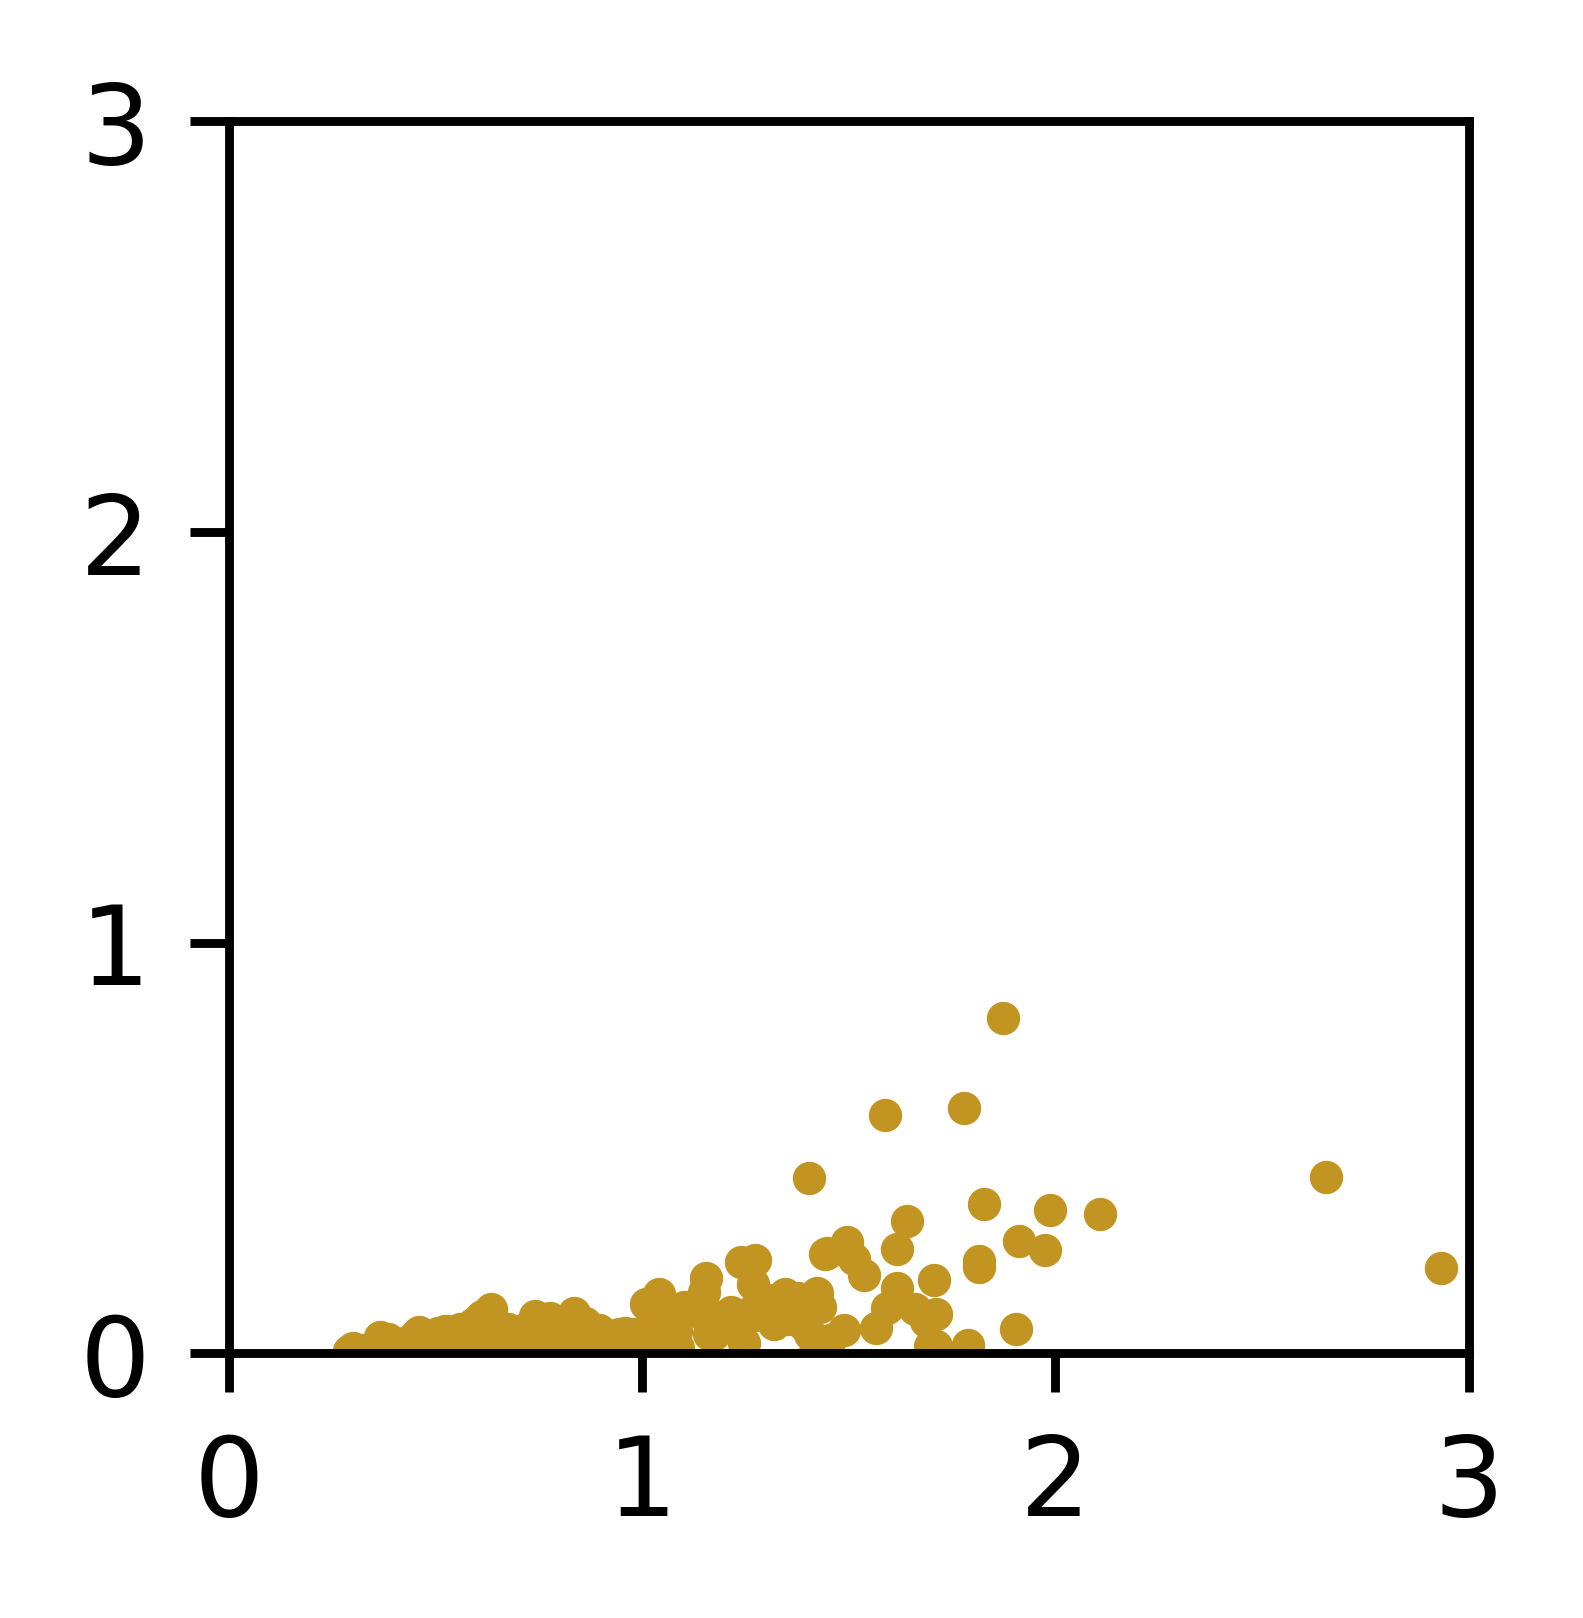

In [18]:
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp7.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']=='7'].X.mean(axis=0),
            s=4,
            c='#c29523'
           )
plt.xlim([0,3])
plt.ylim([0,3])

sampler.cal_metric(sample_interp7, test_adata[test_adata.obs['Group']=='7'])

Day 0: 477, Day 5: 477, Day 7: 477, Day 14: 423, Total: 1854


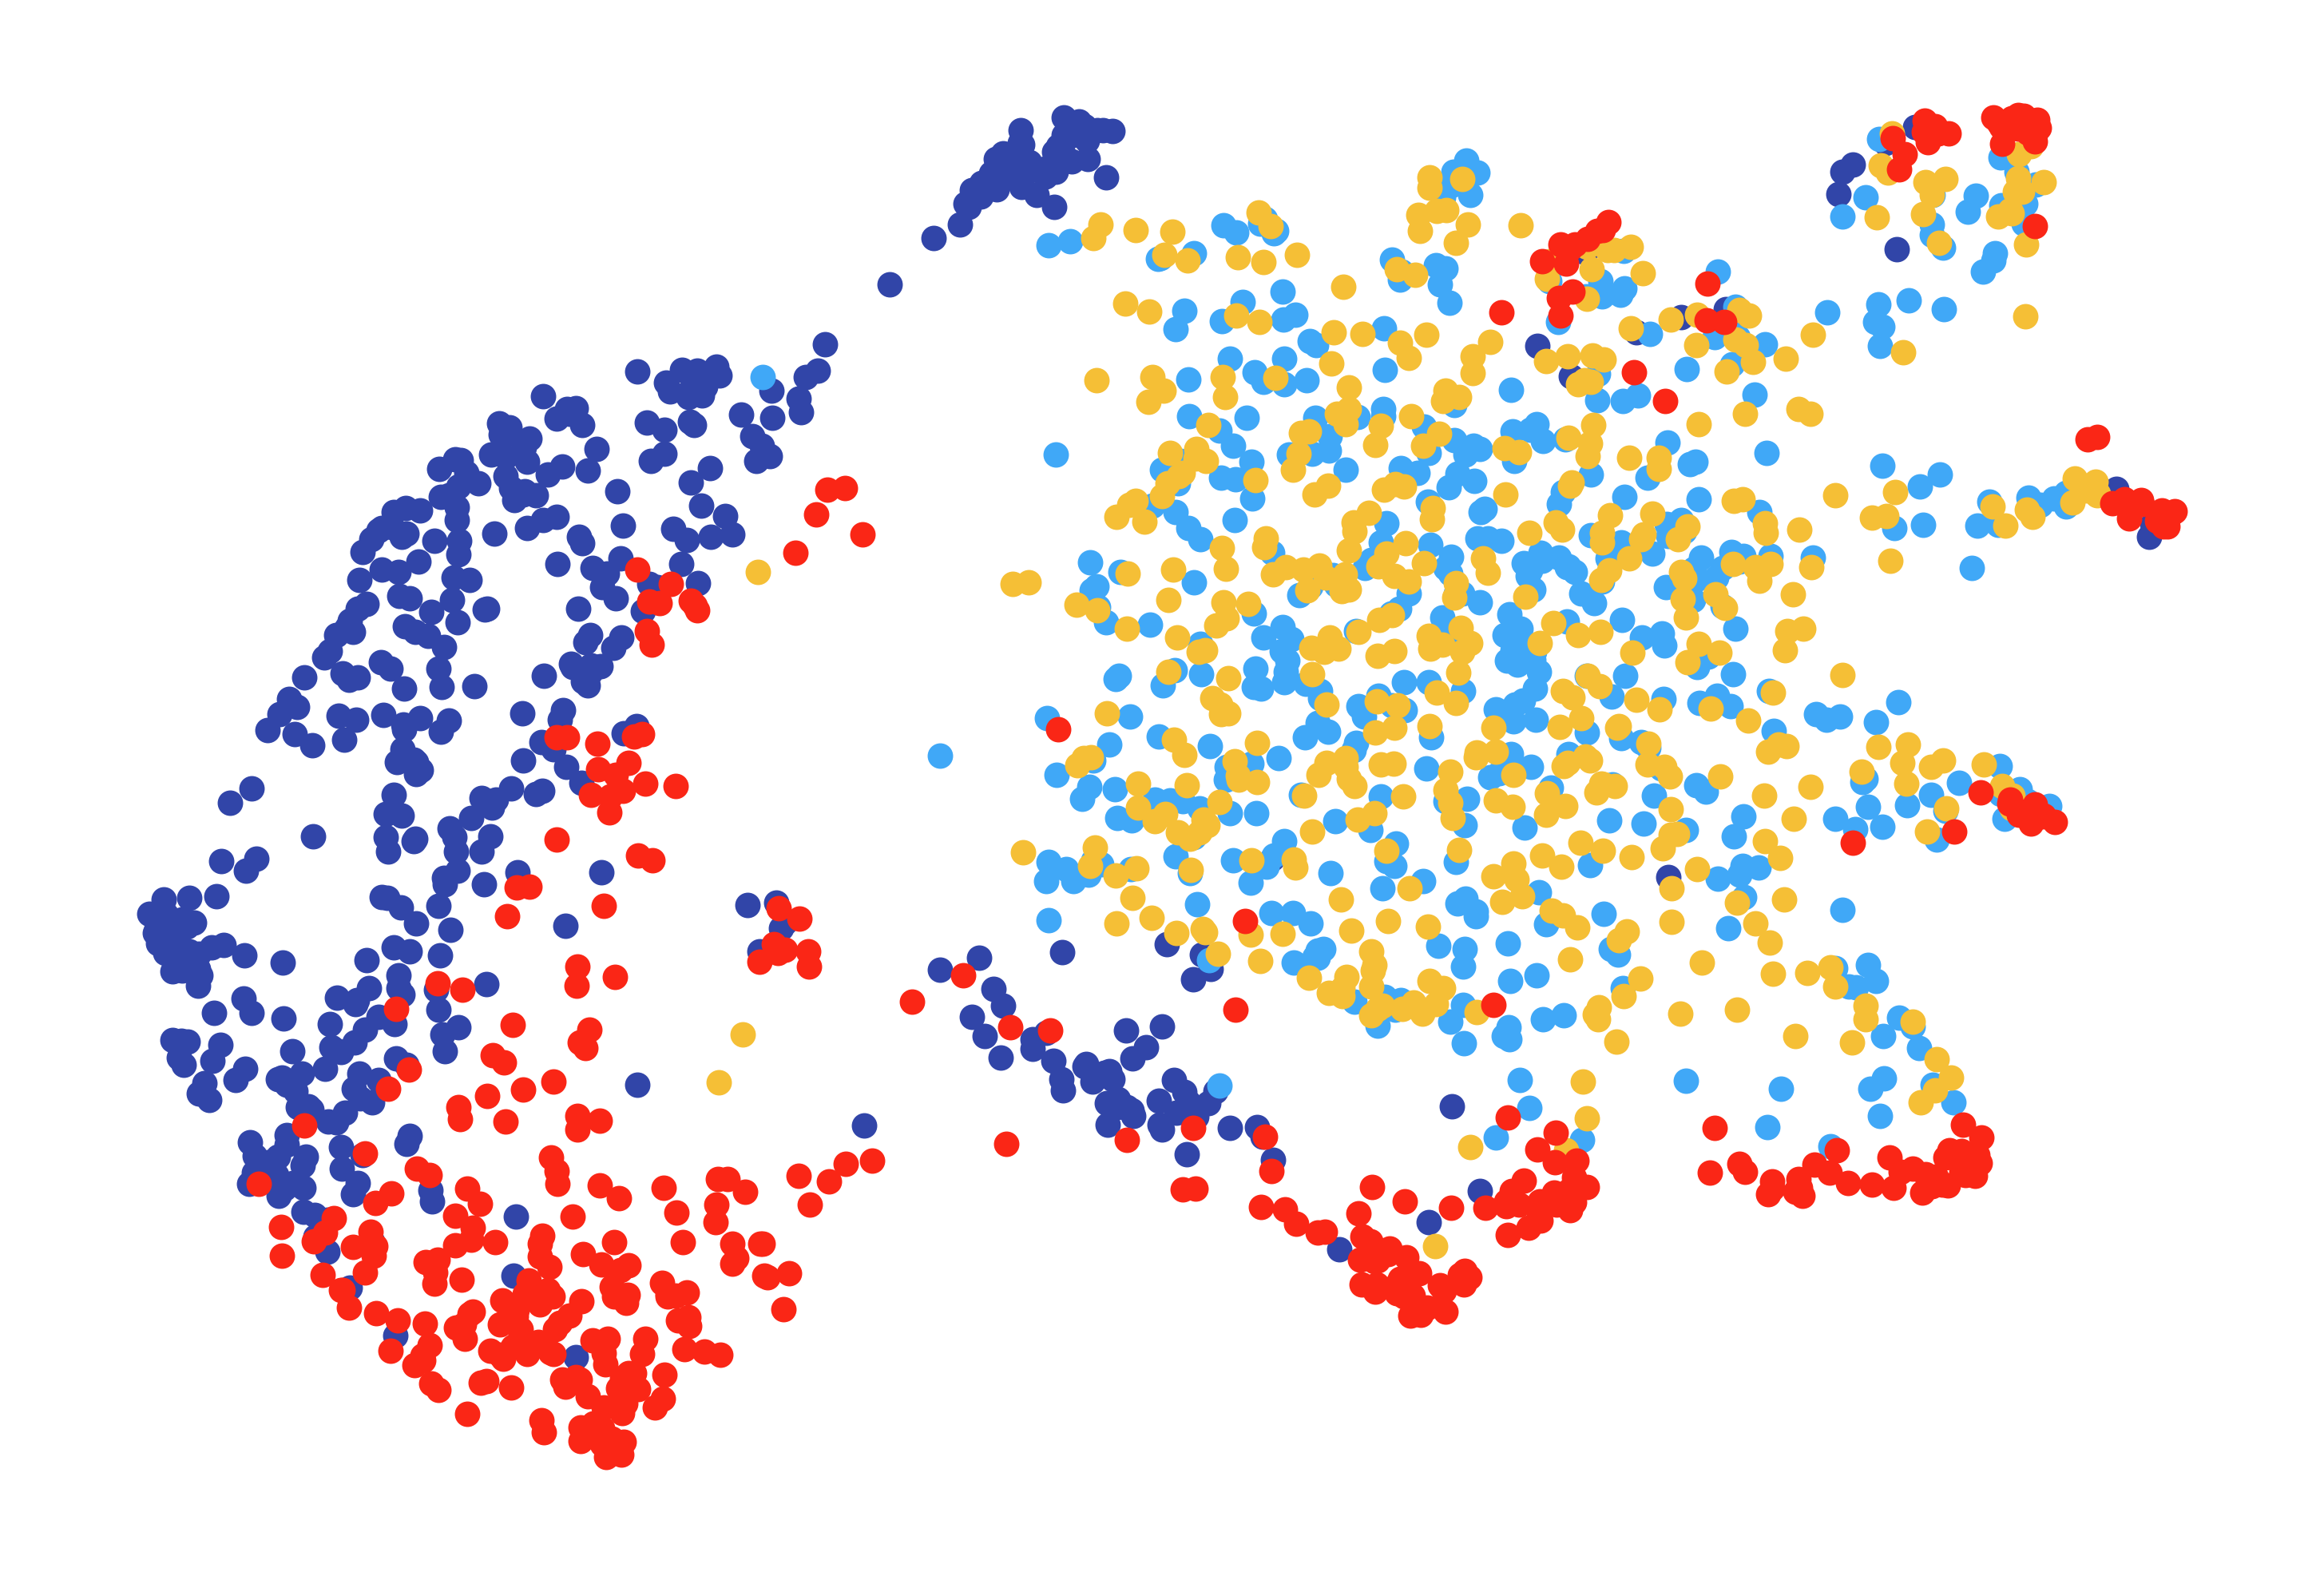

In [21]:
# Combine all points
from sklearn.decomposition import PCA
import umap
combined_points = np.concatenate([sample_interp0.detach().cpu().numpy(),
                                  sample_interp5.detach().cpu().numpy(),
                                  sample_interp7.detach().cpu().numpy(),
                                  sample_interp14.detach().cpu().numpy(),
                                 ], axis=0)

n0   = sample_interp0.shape[0]
n5   = sample_interp5.shape[0]
n7   = sample_interp7.shape[0]
n14  = sample_interp14.shape[0]

print(f"Day 0: {n0}, Day 5: {n5}, Day 7: {n7}, Day 14: {n14}, Total: {n0+n5+n7+n14}")

combined_labels = np.array([0]*n0 + [1]*n5 + [2]*n7 + [3]*n14)

pca = PCA(n_components=30)  # You can adjust the number of components
pca_result = pca.fit_transform(combined_points)
#pca_result

# Perform UMAP with increased neighbors
reducer = umap.UMAP(n_neighbors=50, min_dist=0.2, n_components=2)
embedding_combined = reducer.fit_transform(pca_result)

# Plotting
plt.figure(figsize=(6, 4), dpi=600)
colorlist = ['#3145a8', '#40a8f7', '#f5bf36', '#fa2616']  # Green and Magenta for interpolated points
for i in range(4):
    plt.scatter(embedding_combined[combined_labels == i, 0], 
                embedding_combined[combined_labels == i, 1], 
                c=colorlist[i], 
                s=8, 
                alpha=1)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.axis('off')
#plt.title('UMAP with Linear Interpolation between day0 and day3')
plt.show()


In [22]:
sampler.cal_metric(sample_interp0, test_adata[test_adata.obs['Group']=='0'])

(0.9940518736839294, np.float32(0.99891144))

In [23]:
sampler.cal_metric(sample_interp5, test_adata[test_adata.obs['Group']=='5'])

(-3.1377310752868652, np.float32(0.6666133))

In [24]:
sampler.cal_metric(sample_interp7, test_adata[test_adata.obs['Group']=='7'])

(-2.4350745677948, np.float32(0.70243853))

In [25]:
sampler.cal_metric(sample_interp14, test_adata[test_adata.obs['Group']=='14'])

(0.983140230178833, np.float32(0.99700296))

Results Indicate That Extensive Fine Tuning of the Model is Required to Fit Squiddiff To a Different Dataset

In [33]:
pred_tensor =np.array( torch.cat([sample_interp0,sample_interp5,sample_interp7,sample_interp14], dim=0).detach().cpu())
all_new_data = anndata.AnnData(pred_tensor)
all_new_data.obs['weights'] = combined_labels
all_new_data.obs['weights'] = all_new_data.obs['weights'].astype(str).astype('category')
all_new_data.var_names = test_adata.var_names

sc.tl.rank_genes_groups(all_new_data, groupby='weights', method='wilcoxon')
all_new_data.layers['scaled'] = sc.pp.scale(all_new_data, copy=True).X
marker_genes_dict = {
    '0.0': ['ENSMUSG00000031425', 'ENSMUSG00000037664','ENSMUSG00000061808'],
}

Need to map gene id to Mouse Reference Genome to get actual names, and figure out genes of importance from paper

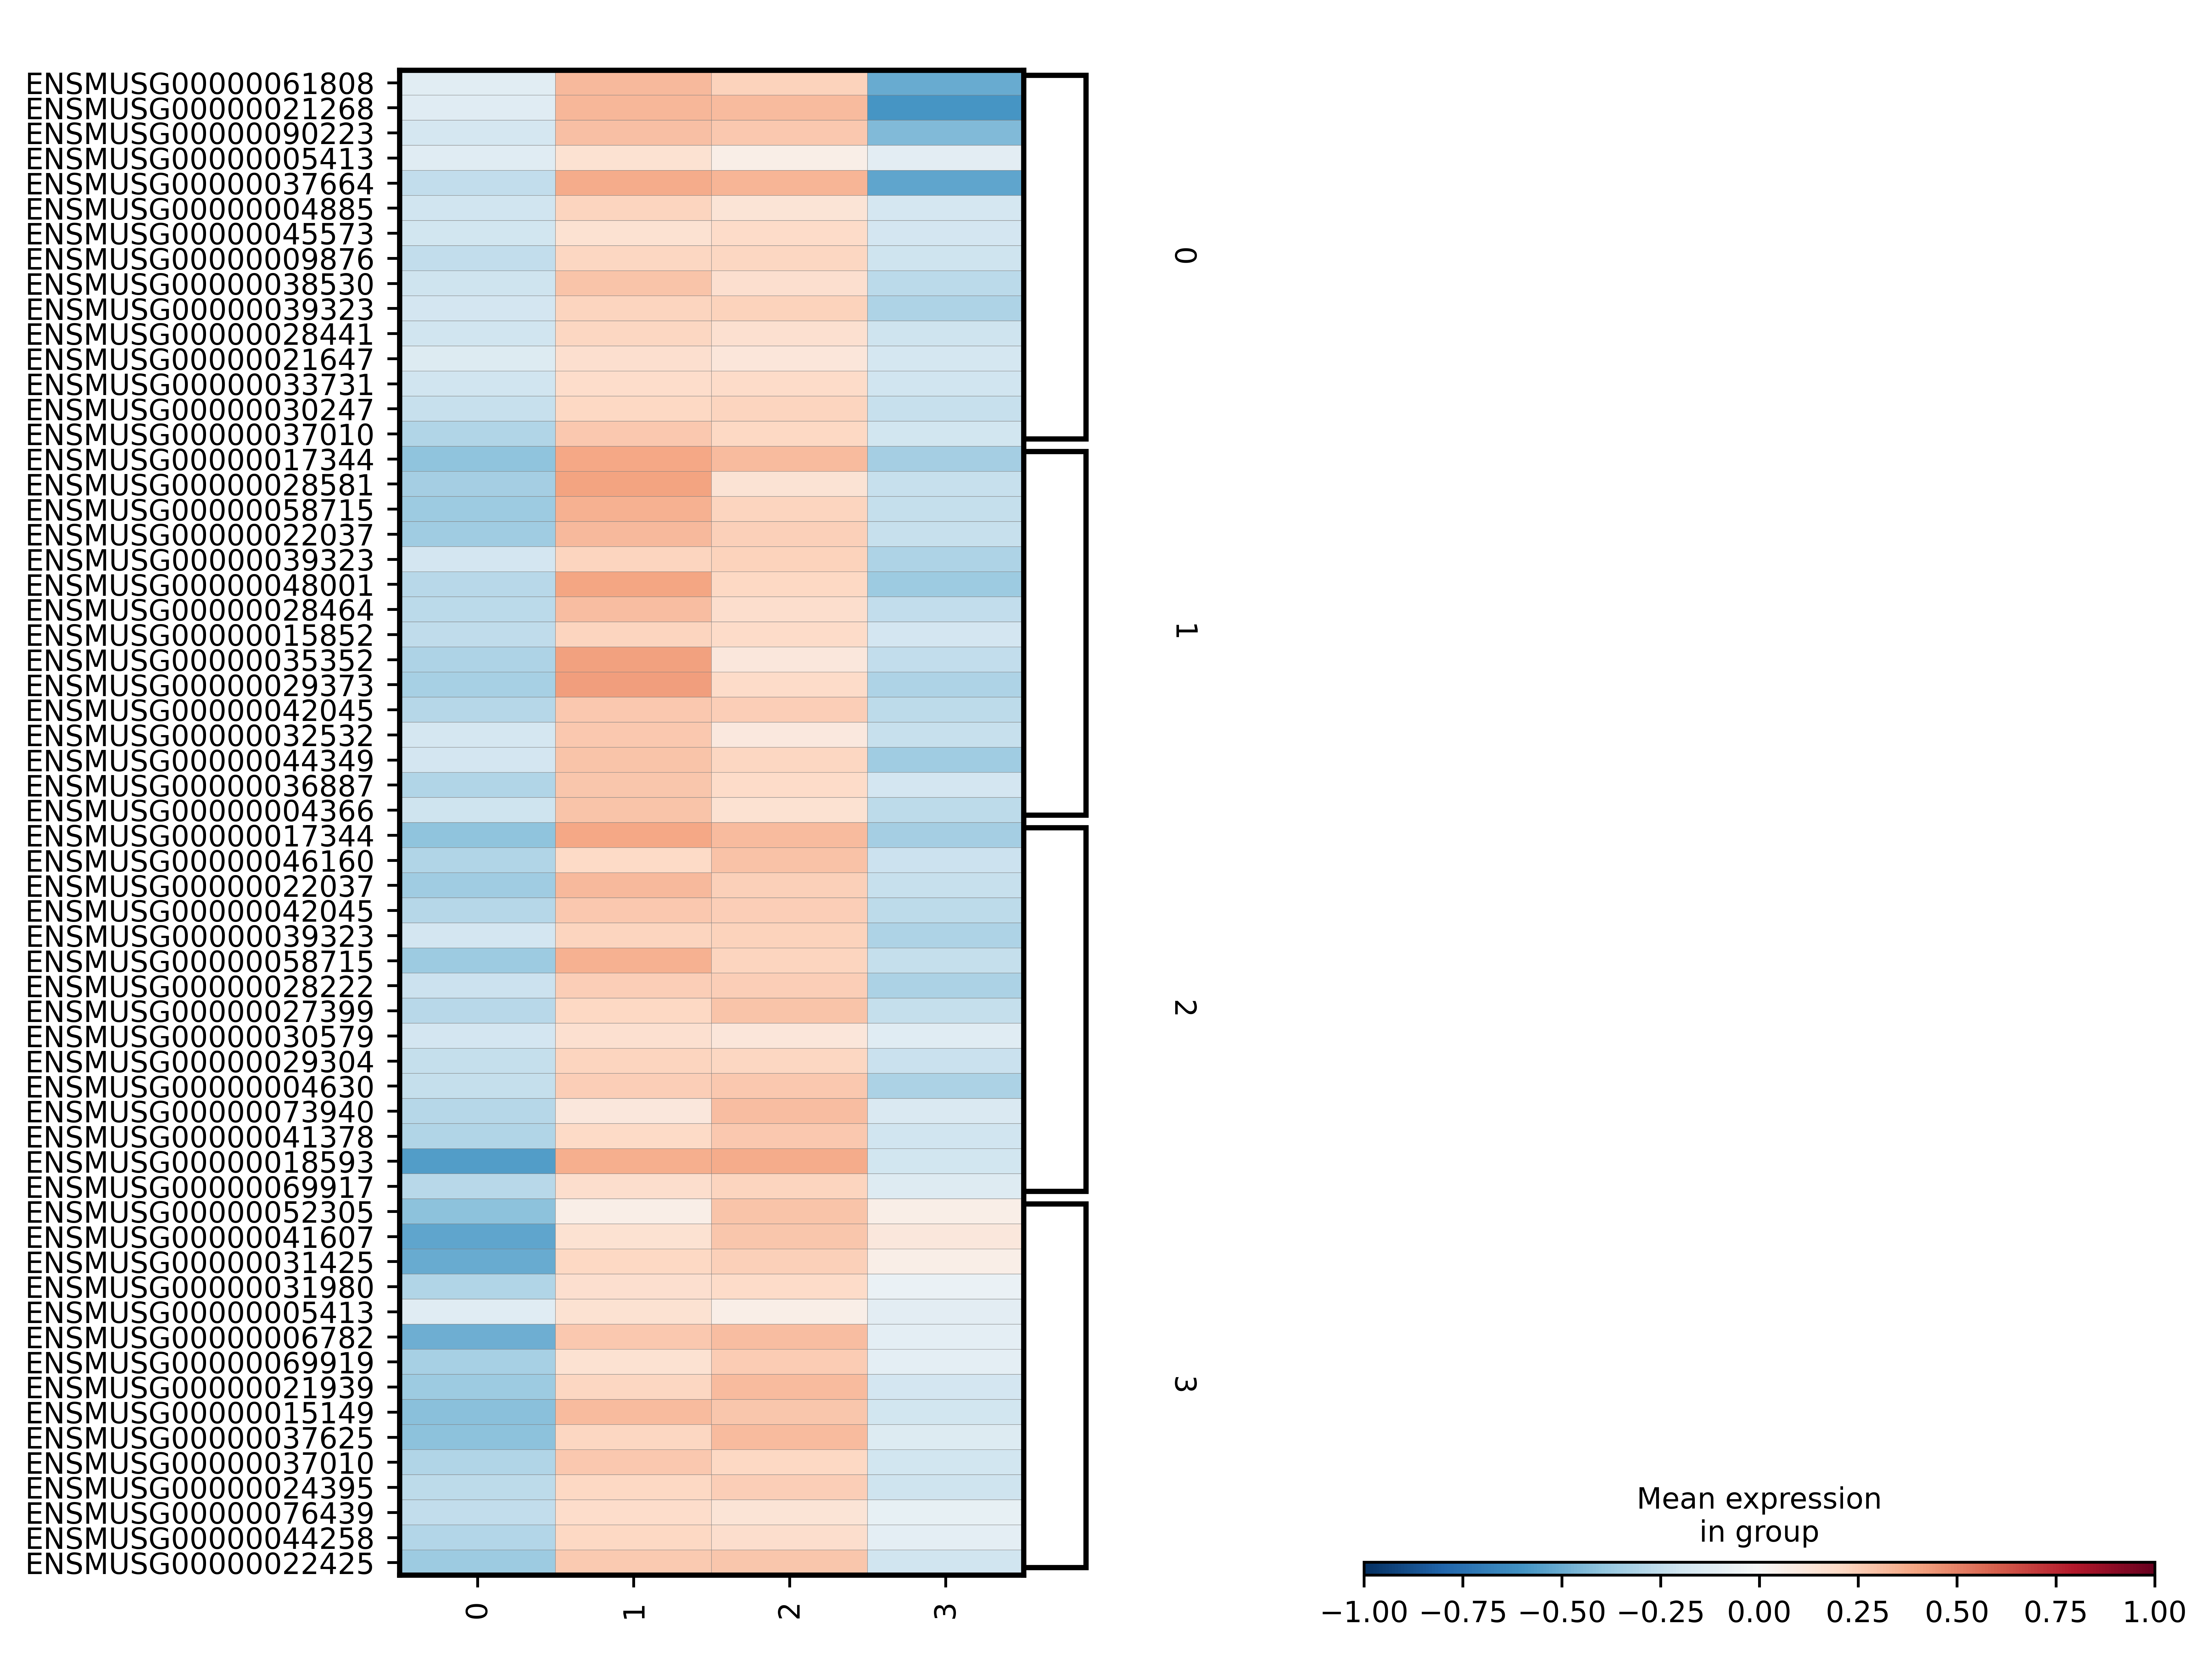

In [31]:
fig,ax = plt.subplots(figsize =(9,8),dpi=800)
sc.pl.rank_genes_groups_matrixplot(all_new_data, 
                                dendrogram=False,
                                n_genes=15, 
                                   use_raw=False, 
                                swap_axes=True, 
                                vmin=-1, vmax=1, 
                                cmap='RdBu_r', 
                                layer='scaled', 
                                   ax=ax,
                                show=True)

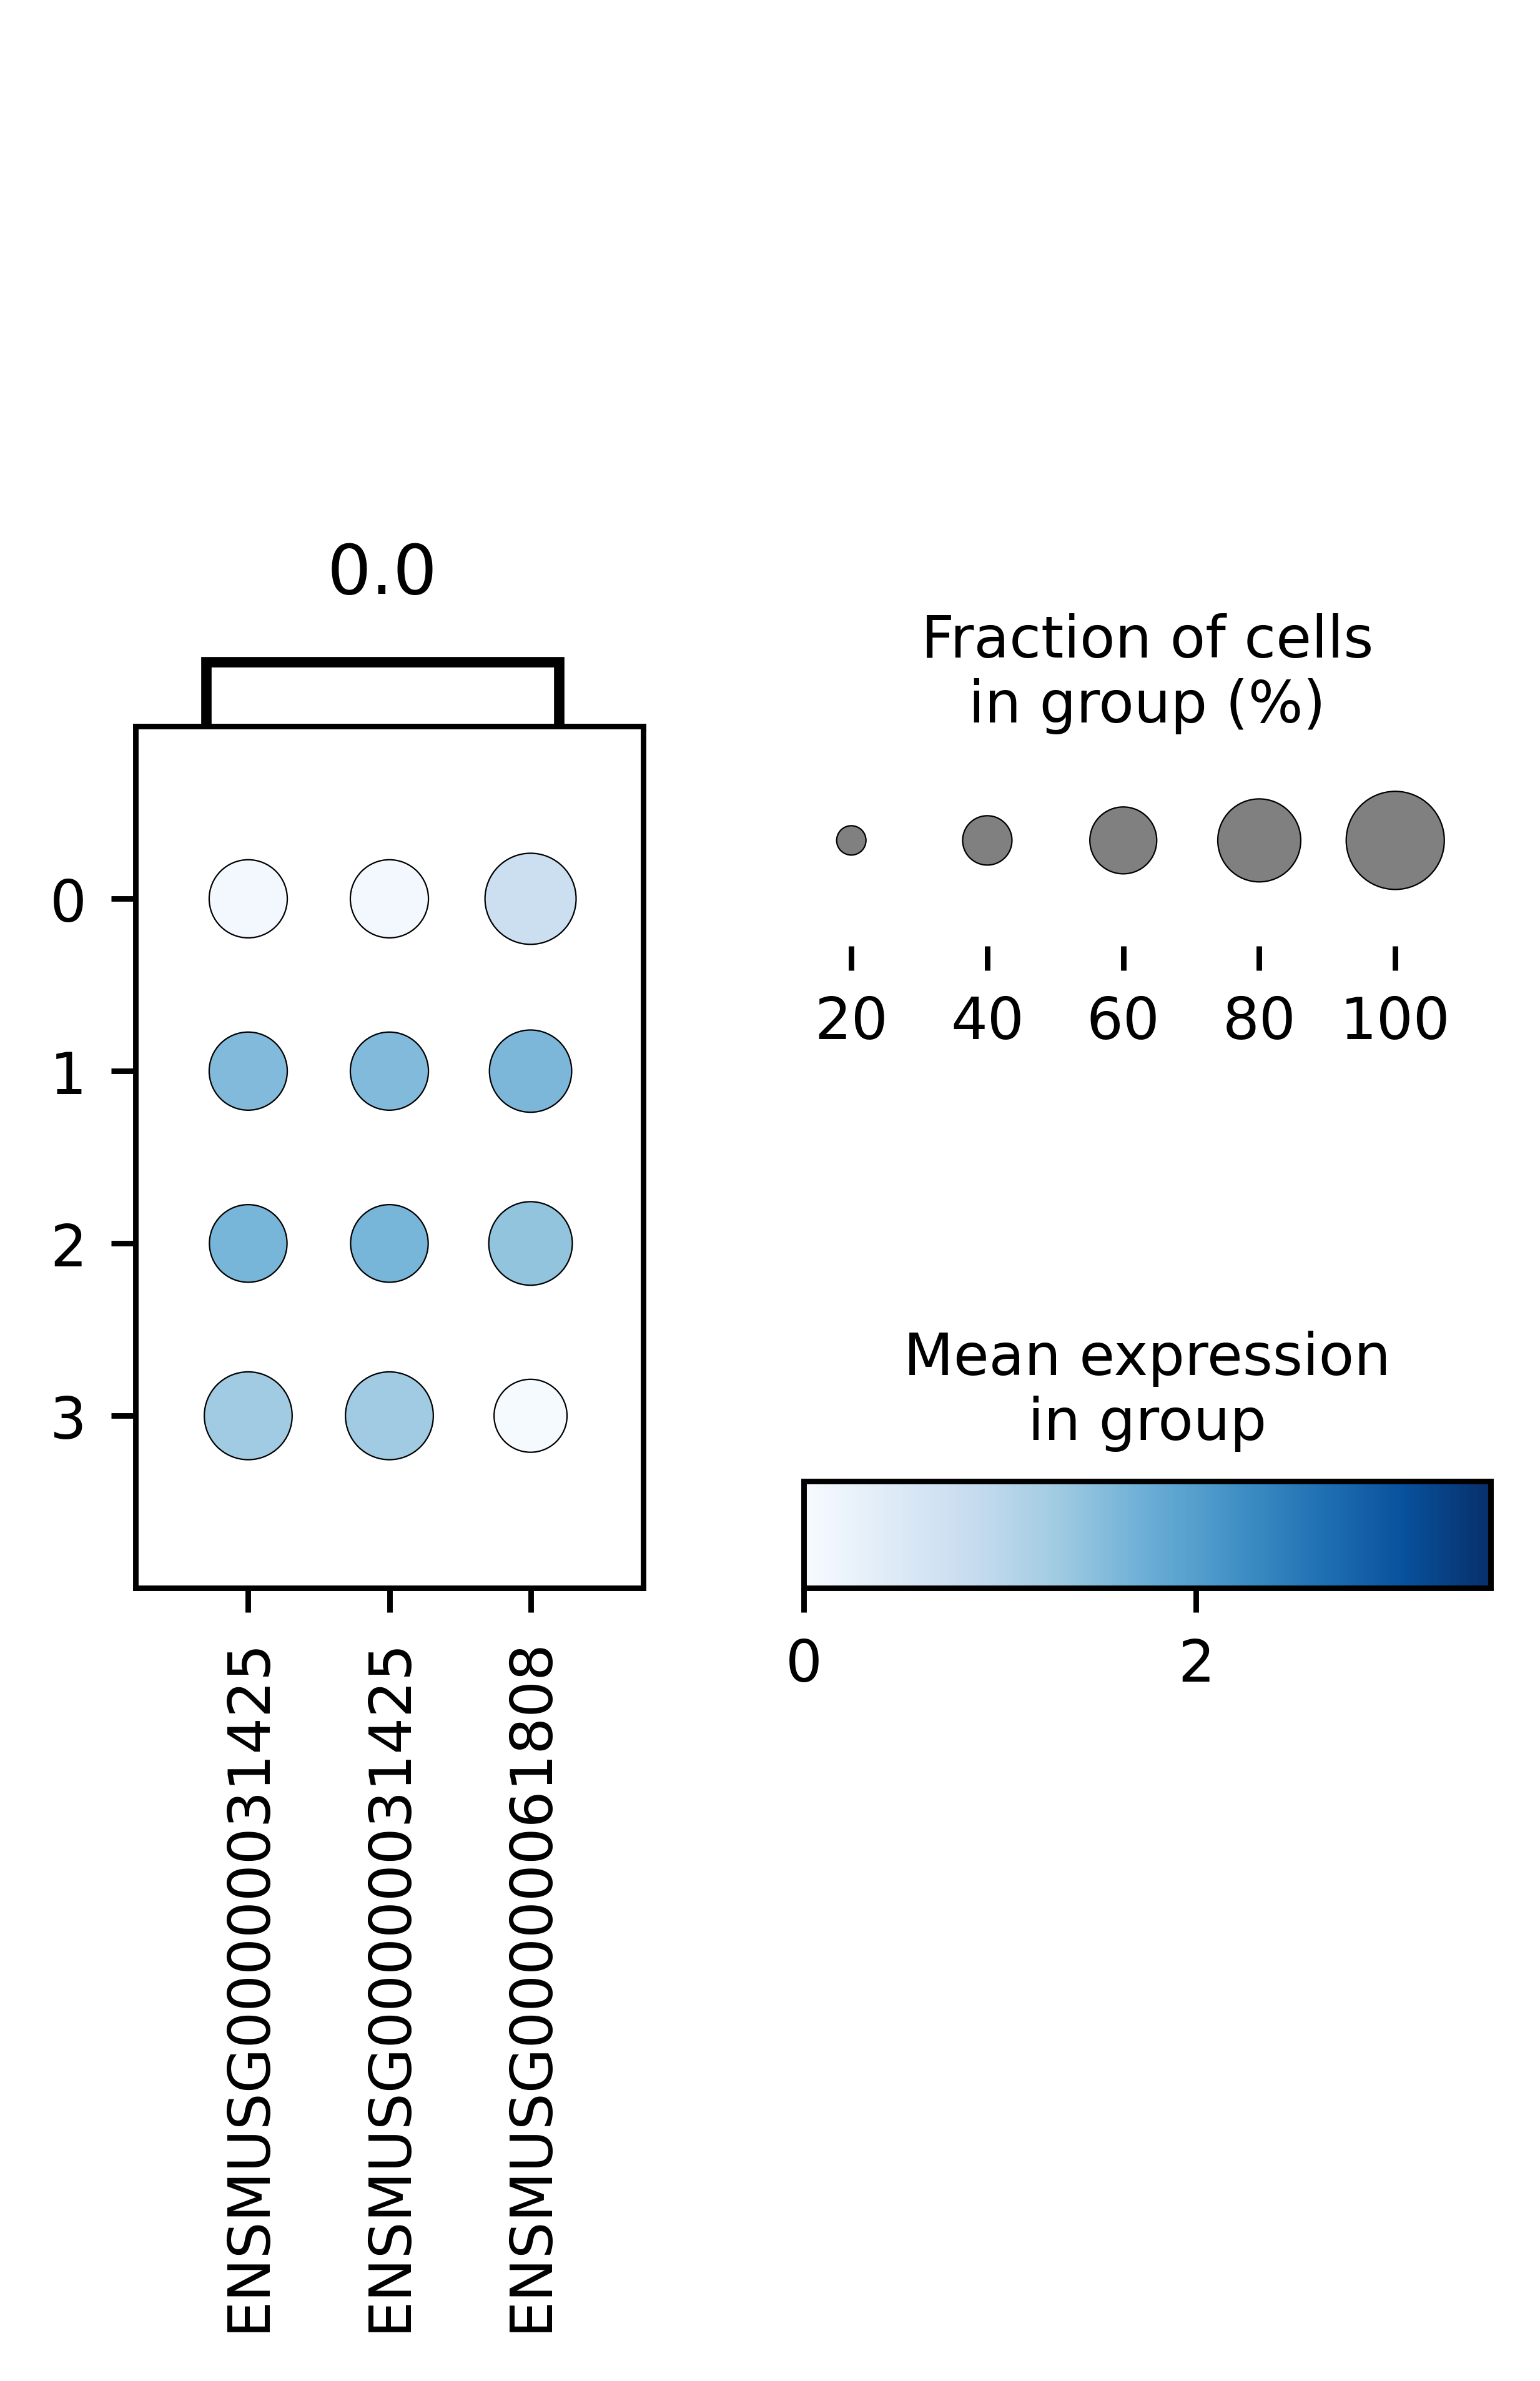

In [32]:
fig,ax = plt.subplots(figsize =(3.5,4),dpi=800)
sc.pl.dotplot(all_new_data, 
              marker_genes_dict, 'weights', 
              vmin=0,
              vmax=3.5,
              dendrogram=False,
              ax=ax,
              cmap='Blues',
             )

ENSMUSG00000031425 = Plp1,ENSMUSG00000037664 = Cdkn1c 